# Noise Robustness — Performance Degradation

Shows how illuminant estimation performance degrades as a function of decreasing SNR.

In [15]:
%reload_ext autoreload
%autoreload 2

import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

REPO_ROOT = os.path.dirname(os.path.abspath(''))
sys.path.insert(0, REPO_ROOT)
from experiment_store import CBCExperimentStore

df_full = CBCExperimentStore(base_dir=os.path.join(REPO_ROOT, 'results'), file_name='cbc_runs_noisy.csv').load()
print(f'Loaded {len(df_full)} runs')
print(df_full.columns.tolist())

Loaded 7 runs
['run_id', 'timestamp', 'experiment_name', 'run_notes', 'dim_red_method', 'camera_rgb_mode', 'camera_model', 'random_projection_seed', 'num_components', 'threshold', 'histogram_bin_count', 'projection_illuminant_names', 'test_illuminant_names', 'snr_db', 'accuracy', 'cross_entropy', 'mean_ang_err', 'median_ang_err', 'trimean_ang_err', 'best25_mean_ang_err', 'worst25_ang_err', 'mean_ang_err_wp', 'median_ang_err_wp', 'trimean_ang_err_wp', 'best25_mean_ang_err_wp', 'worst25_ang_err_wp', 'model_path']


In [16]:
# Display-label aliases 
proj_meth   = "Projection Method"
n_comp      = "# Components (d')"
n_bins      = "# Bins per Dimension (B)"
snr_col     = "SNR (dB)"
threshold   = "Threshold"
ang_mean    = "Mean Angular Error"
ang_med     = "Median Angular Error"
ang_tri     = "Trimean Angular Error"
ang_q1      = "Lower Quartile Mean Angular Error"
ang_q4      = "Upper Quartile Mean Angular Error"
ang_mean_wp = "Mean Angular Error (Whitepoint)"
ang_med_wp  = "Median Angular Error (Whitepoint)"
ang_tri_wp  = "Trimean Angular Error (Whitepoint)"
ang_q1_wp   = "Lower Quartile Mean Angular Error (Whitepoint)"
ang_q4_wp   = "Upper Quartile Mean Angular Error (Whitepoint)"
accuracy    = "Accuracy"

rename_map = {
    "run_id":                  "Run ID",
    "timestamp":               "Timestamp",
    "experiment_name":         "Experiment",
    "run_notes":               "Notes",
    "dim_red_method":          proj_meth,
    "camera_rgb_mode":         "Camera RGB Mode",
    "camera_model":            "Camera Model",
    "num_components":          n_comp,
    "threshold":               threshold,
    "histogram_bin_count":     n_bins,
    "snr_db":                  snr_col,
    "accuracy":                accuracy,
    "cross_entropy":           "Cross-Entropy",
    "mean_ang_err":            ang_mean,
    "median_ang_err":          ang_med,
    "trimean_ang_err":         ang_tri,
    "best25_mean_ang_err":     ang_q1,
    "worst25_ang_err":         ang_q4,
    "mean_ang_err_wp":         ang_mean_wp,
    "median_ang_err_wp":       ang_med_wp,
    "trimean_ang_err_wp":      ang_tri_wp,
    "best25_mean_ang_err_wp":  ang_q1_wp,
    "worst25_ang_err_wp":      ang_q4_wp,
    "model_path":              "Model Path",
}

dim_red_value_map = {
    "DimRedMethod.CAM":     "RGB",
    "DimRedMethod.PCA":     "PCA",
    "DimRedMethod.ILL_PCA": "Ill-PCA",
    "DimRedMethod.NMF":     "NNMF",
    "DimRedMethod.LDA":     "LDA",
    "DimRedMethod.DL":      "DL",
    "DimRedMethod.RAND":    "RAND",
}

df_full["dim_red_method"] = (
    df_full["dim_red_method"].astype(str)
    .map(dim_red_value_map)
    .fillna(df_full["dim_red_method"].astype(str))
)

df_full = df_full.rename(columns=rename_map)

# ── SNR labels derived from whatever values are in the data ───────────────
# NaN (no noise) → "Clean", floats → "X dB", ordered best → worst SNR.
def snr_label(val) -> str:
    return "Clean" if pd.isna(val) else f"{val:.0f} dB"

snr_values_sorted = sorted(
    df_full[snr_col].unique(),
    key=lambda v: (not pd.isna(v), -v if not pd.isna(v) else 0),  # NaN first, then descending
)
SNR_ORDER = [snr_label(v) for v in snr_values_sorted]
print("SNR levels found:", SNR_ORDER)

df_full["snr_label"] = df_full[snr_col].map(snr_label)
df_full["snr_label"] = pd.Categorical(df_full["snr_label"], categories=SNR_ORDER, ordered=True)

display(df_full)

SNR levels found: ['Clean', '50 dB', '40 dB', '30 dB', '20 dB']


,Run ID,Timestamp,Experiment,Notes,Projection Method,Camera RGB Mode,Camera Model,random_projection_seed,# Components (d'),Threshold,...,Trimean Angular Error,Lower Quartile Mean Angular Error,Upper Quartile Mean Angular Error,Mean Angular Error (Whitepoint),Median Angular Error (Whitepoint),Trimean Angular Error (Whitepoint),Lower Quartile Mean Angular Error (Whitepoint),Upper Quartile Mean Angular Error (Whitepoint),Model Path,snr_label
0,33b9146b-f1c7-463f-b305-75daf76d0a46,2026-04-13T13:18:05Z,,,Ill-PCA,None,,<NA>,4,True,...,1.463726,0.0,13.632293,2.242898,0.027976,0.793057,0.000000,7.721722,models/cbc_histograms/36f8db9a-f58a-4c7d-95a2-...,Clean
1,12af36c8-efd8-4a8a-b370-e58eb6f4738f,2026-04-13T13:23:13Z,,,Ill-PCA,None,,<NA>,4,True,...,1.463726,0.0,13.613354,2.253115,0.027976,0.793057,0.000000,7.677138,models/cbc_histograms/55d3725b-3bb9-411f-816d-...,50 dB
2,6a07eaff-391e-44f7-81bb-dc6576af3c84,2026-04-13T13:28:30Z,,,Ill-PCA,None,,<NA>,4,True,...,1.799141,0.0,14.405948,2.331496,0.027976,0.852994,0.000000,7.933898,models/cbc_histograms/230e8b73-1a15-4a68-b793-...,40 dB
3,c0bfc1eb-7dfe-498f-9a40-743c425a25cc,2026-04-13T13:33:31Z,,,Ill-PCA,None,,<NA>,4,True,...,2.262714,0.0,16.134110,2.728710,0.034264,1.178940,0.007476,8.811124,models/cbc_histograms/6cc95e5f-c5f9-4da3-b3b1-...,30 dB
4,65d06d95-5c24-4f48-baf1-cfc2a8f4ce78,2026-04-13T13:38:42Z,,,Ill-PCA,None,,<NA>,4,True,...,4.385022,0.0,18.787190,3.610383,1.079015,2.221636,0.007441,10.443808,models/cbc_histograms/3026dcbc-383c-475b-a413-...,20 dB
5,4ea3055d-d4cb-4a44-a00d-d4e2963f253f,2026-04-14T08:47:52Z,,,RAND,None,,43,3,True,...,6.376168,0.0,24.960270,4.926944,2.262178,3.284043,0.008036,14.572432,models/cbc_histograms/3be68581-cb43-4ed6-ba13-...,Clean
6,79cc95a9-7699-44bf-87c4-82a67102c8ab,2026-04-14T08:52:12Z,,,Ill-PCA,None,,<NA>,3,True,...,2.710112,0.0,18.177856,2.958032,0.034264,1.239853,0.000000,9.426732,models/cbc_histograms/3057445b-744f-4483-82be-...,Clean


In [17]:
# ── Global plot style ──────────────────────────────────────────────────────
fs = 12
mpl.rcParams.update({
    "font.size":        fs,
    "axes.labelsize":   fs,
    "axes.titlesize":   fs,
    "xtick.labelsize":  fs,
    "ytick.labelsize":  fs,
    "legend.fontsize":  fs,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
})

## Degradation across SNR levels

One line per method, x-axis = SNR label (Clean → noisy), y-axis = mean angular error.
Adjust the filter below to match whatever settings you ran.

In [18]:
# ── Filter to a fixed (d', B, threshold) operating point ──────────────────
D_PRIME = 4
B       = 20

mask = (
    df_full[n_comp].eq(D_PRIME) &
    df_full[n_bins].eq(B) &
    df_full[threshold].eq(True)
)
df_snr = df_full.loc[mask].copy()
print(f'{len(df_snr)} rows after filtering')
display(df_snr[[proj_meth, n_comp, n_bins, "snr_label", ang_mean, ang_mean_wp, accuracy]])

5 rows after filtering


,Projection Method,# Components (d'),# Bins per Dimension (B),snr_label,Mean Angular Error,Mean Angular Error (Whitepoint),Accuracy
0,Ill-PCA,4,20,Clean,4.052170,2.242898,0.618874
1,Ill-PCA,4,20,50 dB,4.067458,2.253115,0.616528
2,Ill-PCA,4,20,40 dB,4.280610,2.331496,0.602190
3,Ill-PCA,4,20,30 dB,5.000032,2.728710,0.566215
4,Ill-PCA,4,20,20 dB,6.732112,3.610383,0.477059


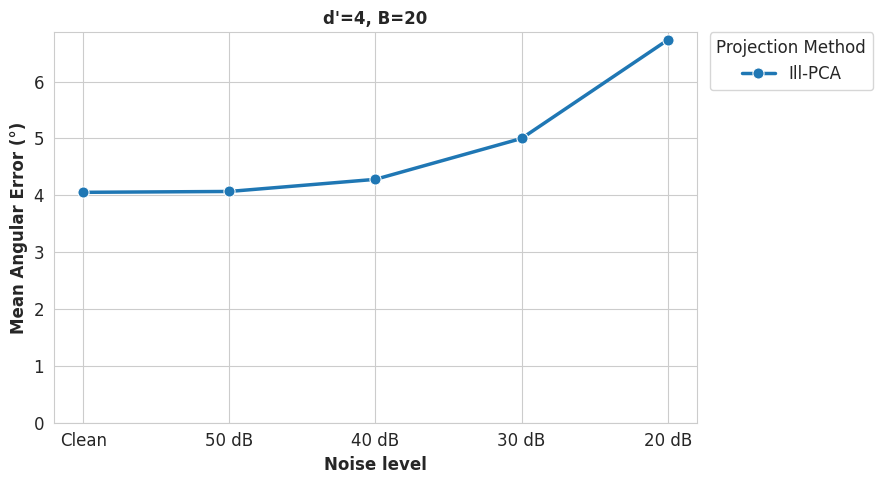

In [19]:
# ── Mean angular error vs SNR, one line per method ────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

sns.lineplot(
    data=df_snr,
    x="snr_label",
    y=ang_mean,
    hue=proj_meth,
    marker="o",
    linewidth=2.5,
    markersize=8,
    ax=ax,
)

ax.set_xlabel("Noise level")
ax.set_ylabel(ang_mean + " (°)")
ax.set_title(f"d'={D_PRIME}, B={B}")
ax.legend(title=proj_meth, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

In [20]:
def make_latex_noise_stats_table(
        df,
        *,
        method="Ill-PCA",
        d_prime=4,
        B=20,
        method_col=proj_meth,
        d_col=n_comp,
        B_col=n_bins,
        snr_label_col="snr_label",
        threshold_col=threshold,
        stats=(ang_mean, ang_tri, ang_q1, ang_q4),
        stat_labels=("Mean", "Trimean", "Best-25\\%", "Worst-25\\%"),
        snr_order=None,
        float_fmt="%.2f",
):
    """
    Rows: noise levels (Clean, X dB, ...)
    Cols: error statistics
    Filters to a fixed (method, d', B) operating point.
    """
    mask = (
            df[method_col].eq(method) &
            df[d_col].eq(d_prime) &
            df[B_col].eq(B) &
            df[threshold_col].eq(True)
    )
    sub = df.loc[mask].copy()

    if snr_order is None:
        if hasattr(sub[snr_label_col], "cat"):
            snr_order = [s for s in sub[snr_label_col].cat.categories
                         if s in sub[snr_label_col].unique()]
        else:
            snr_order = sorted(sub[snr_label_col].unique())

    agg = (
        sub.groupby(snr_label_col, observed=True)[list(stats)]
        .mean()
        .reindex(snr_order)
    )

    def fmt(x):
        return "--" if pd.isna(x) else float_fmt % float(x)

    lines = [
        r"\begin{tabular}{l" + "c" * len(stats) + r"}",
        r"\toprule",
        "Noise level & " + " & ".join(stat_labels) + r" \\",
        r"\midrule",
    ]
    for snr in snr_order:
        if snr not in agg.index:
            continue
        row = [snr] + [fmt(agg.loc[snr, stat]) for stat in stats]
        lines.append(" & ".join(row) + r" \\")
    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")

    return "\n".join(lines)


latex_noise = make_latex_noise_stats_table(
    df_full,
    method="Ill-PCA",
    d_prime=4,
    B=20,
)

print(r"\begin{table}[t]")
print(r"\centering")
print(r"\caption{Extended angular error statistics (degrees) for Ill-PCA at $d'=4$, $B=20$ across noise levels. Lower is better.}")
print(r"\label{tab:appx_noise_illpca}")
print(latex_noise)
print(r"\end{table}")

\begin{table}[t]
\centering
\caption{Extended angular error statistics (degrees) for Ill-PCA at $d'=4$, $B=20$ across noise levels. Lower is better.}
\label{tab:appx_noise_illpca}
\begin{tabular}{lcccc}
\toprule
Noise level & Mean & Trimean & Best-25\% & Worst-25\% \\
\midrule
Clean & 4.05 & 1.46 & 0.00 & 13.63 \\
50 dB & 4.07 & 1.46 & 0.00 & 13.61 \\
40 dB & 4.28 & 1.80 & 0.00 & 14.41 \\
30 dB & 5.00 & 2.26 & 0.00 & 16.13 \\
20 dB & 6.73 & 4.39 & 0.00 & 18.79 \\
\bottomrule
\end{tabular}
\end{table}


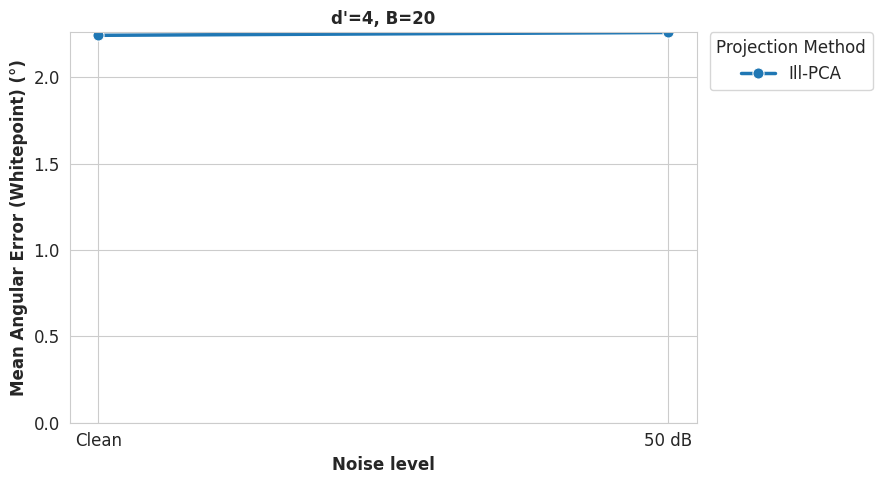

In [34]:
# ── Whitepoint angular error vs SNR ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

sns.lineplot(
    data=df_snr,
    x="snr_label",
    y=ang_mean_wp,
    hue=proj_meth,
    marker="o",
    linewidth=2.5,
    markersize=8,
    ax=ax,
)

ax.set_xlabel("Noise level")
ax.set_ylabel(ang_mean_wp + " (°)")
ax.set_title(f"d'={D_PRIME}, B={B}")
ax.legend(title=proj_meth, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

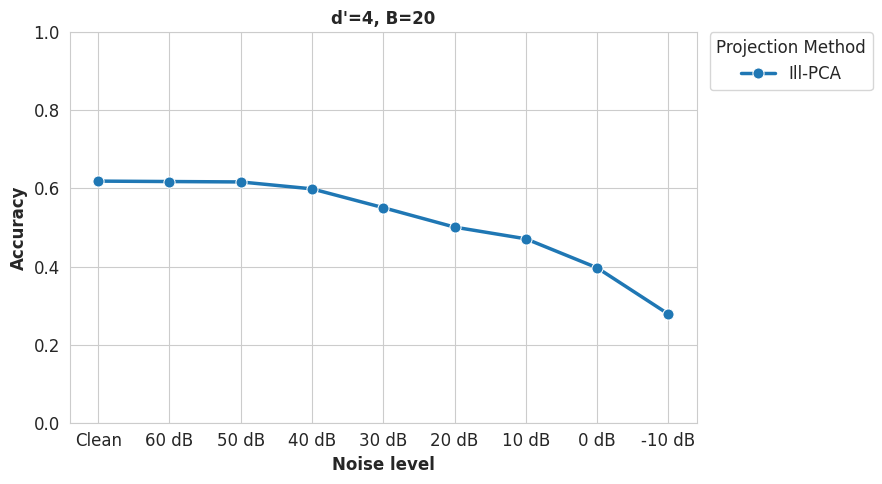

In [26]:
# ── Accuracy vs SNR ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

sns.lineplot(
    data=df_snr,
    x="snr_label",
    y=accuracy,
    hue=proj_meth,
    marker="o",
    linewidth=2.5,
    markersize=8,
    ax=ax,
)

ax.set_xlabel("Noise level")
ax.set_ylabel(accuracy)
ax.set_title(f"d'={D_PRIME}, B={B}")
ax.legend(title=proj_meth, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## Side-by-side: spectral vs whitepoint error across SNR

Two panels on one figure — useful for a paper figure.

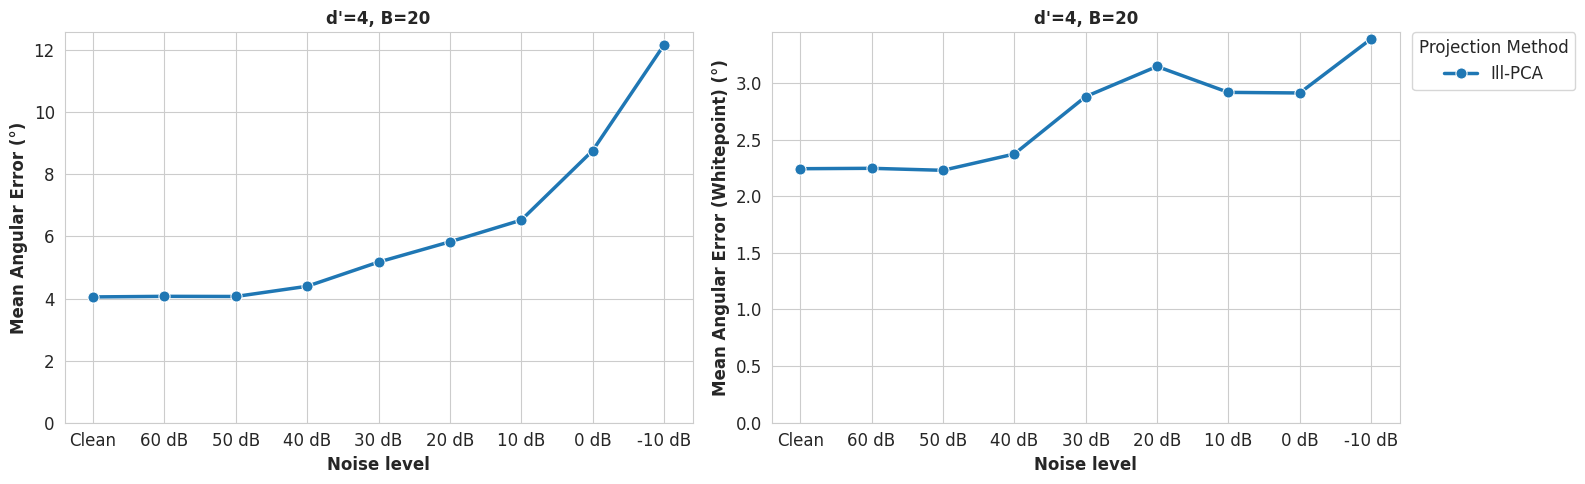

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

for ax, metric, ylabel in zip(
    axes,
    [ang_mean, ang_mean_wp],
    [ang_mean + " (°)", ang_mean_wp + " (°)"],
):
    sns.lineplot(
        data=df_snr,
        x="snr_label",
        y=metric,
        hue=proj_meth,
        marker="o",
        linewidth=2.5,
        markersize=8,
        ax=ax,
        legend=(ax is axes[-1]),
    )
    ax.set_xlabel("Noise level")
    ax.set_ylabel(ylabel)
    ax.set_title(f"d'={D_PRIME}, B={B}")
    ax.set_ylim(bottom=0)

axes[-1].legend(title=proj_meth, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

plt.tight_layout()
plt.show()

## Degradation across multiple (d', B) settings

Facet grid: one panel per d' value, lines = SNR levels.

In [28]:
METHOD_TO_PLOT = "RAND"   # pick one method to keep the grid readable

mask_m = (
    df_full[proj_meth].eq(METHOD_TO_PLOT) &
    df_full[threshold].eq(True)
)
df_method = df_full.loc[mask_m].copy()

d_values = sorted(df_method[n_comp].dropna().unique())
ncols = len(d_values)

fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5), sharey=True)
if ncols == 1:
    axes = [axes]

palette = sns.color_palette("muted", n_colors=len(SNR_ORDER))
hue_palette = dict(zip(SNR_ORDER, palette))

for ax, d in zip(axes, d_values):
    df_d = df_method[df_method[n_comp].eq(d)]
    sns.lineplot(
        data=df_d,
        x=n_bins,
        y=ang_mean,
        hue="snr_label",
        hue_order=SNR_ORDER,
        palette=hue_palette,
        marker="o",
        linewidth=2.5,
        markersize=7,
        ax=ax,
        legend=(ax is axes[-1]),
    )
    ax.set_title(f"d'={int(d)}  ({METHOD_TO_PLOT})")
    ax.set_xlabel(n_bins)
    ax.set_ylabel(ang_mean + " (°)" if ax is axes[0] else "")
    ax.set_ylim(bottom=0)

axes[-1].legend(title="Noise level", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)

plt.suptitle(f"{METHOD_TO_PLOT} — effect of noise across d' and B", y=1.02)
plt.tight_layout()
plt.show()

ValueError: Number of columns must be a positive integer, not 0

<Figure size 0x500 with 0 Axes>